In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import umap
import numpy as np

In [ ]:
data = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/whole_slide/o8p_day24_s12.csv")
data = data.drop(columns=["label","label.1", 'nuclei_i', 'nuclei_j', 'nuclei_bounds'])
df = data[['foci_count'] + [col for col in data.columns if col != 'foci_count']]

In [51]:
data = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/whole_slide/o8p_day24_s12.csv")
data

,label,label.1,nuclei_area,nuclei_i,nuclei_j,nuclei_bounds,foci_count,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
0,1,1,2717.0,702.826279,23104.128082,"(684, 23056, 735, 23154)",4,84,1,0.269625,45.028147,356.689278,63.122746
1,2,2,1672.0,725.440191,23143.065789,"(705, 23106, 741, 23177)",0,0,1,0.373206,45.028147,338.722585,110.067377
2,3,3,47858.0,827.004931,19604.518137,"(718, 19474, 959, 19746)",115,2292,0,0.000000,2285.094352,2508.669848,75.143949
3,4,4,69456.0,846.331606,24623.286484,"(722, 24436, 973, 24808)",209,2352,0,0.000000,1485.149163,1525.921370,0.727305
4,5,5,1799.0,1058.934964,23083.784880,"(1030, 23064, 1088, 23101)",4,39,0,0.000000,338.722585,356.689278,6.809877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5579,5580,5580,313.0,41141.648562,21164.952077,"(41132, 21155, 41151, 21177)",0,0,0,0.000000,198.964734,650.819766,29.652683
5580,5581,5581,344.0,41229.020349,20986.197674,"(41221, 20971, 41239, 20999)",0,0,0,0.000000,198.964734,487.943582,138.708792
5581,5582,5582,622.0,41330.006431,23561.048232,"(41315, 23547, 41349, 23576)",0,0,1,0.157025,24.680533,53.098282,28.441146
5582,5583,5583,586.0,41327.680887,23614.095563,"(41316, 23593, 41341, 23633)",0,0,0,0.000000,33.524676,53.098282,20.524922


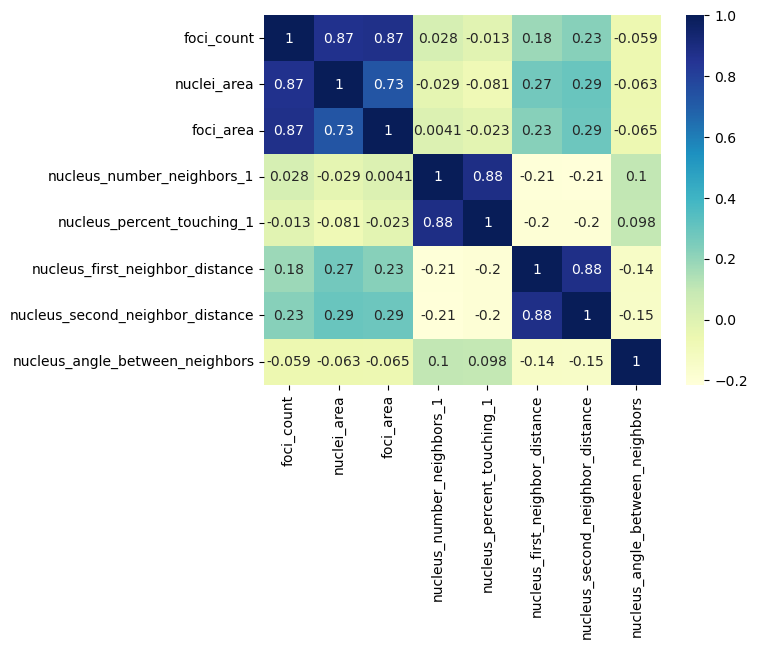

In [14]:
# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

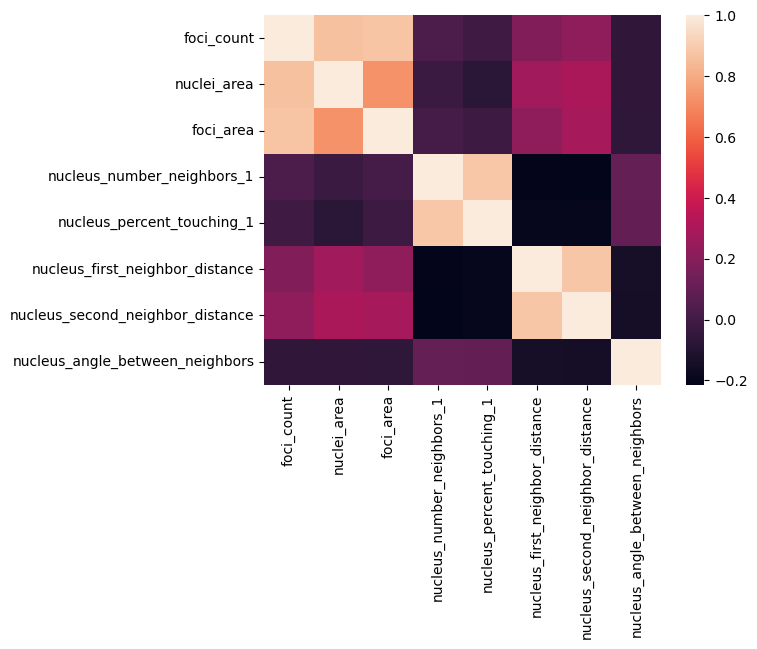

In [16]:

# Plotting correlation heatmap
dataplot = sns.heatmap(df.corr(numeric_only=True))

# Displaying heatmap
plt.show()

In [19]:
scaled_statistics = StandardScaler().fit_transform(df)

type(scaled_statistics), scaled_statistics.shape

(numpy.ndarray, (5584, 8))

In [28]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(scaled_statistics)
type(embedding), embedding.shape

(numpy.ndarray, (5584, 2))

Text(0, 0.5, 'UMAP2')

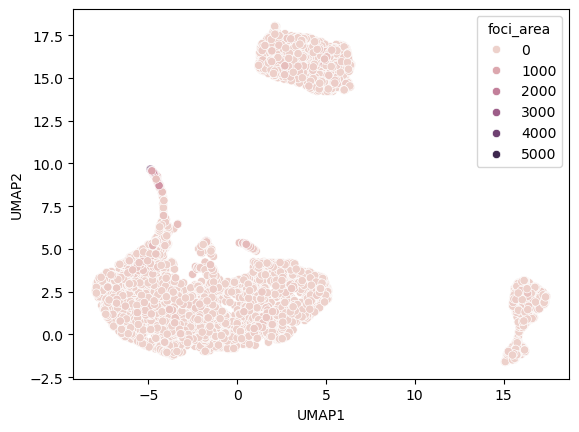

In [98]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    data = df,
                    hue='foci_area')

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

<Axes: >

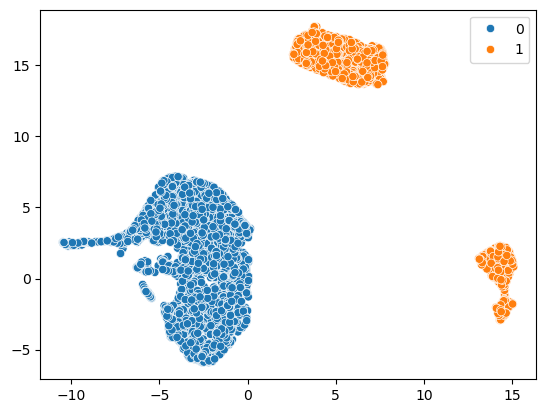

In [26]:
num_classes = 2

kmeans = KMeans(n_clusters=num_classes, random_state=42).fit(embedding)

kmeans_prediction = kmeans.predict(embedding)

sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

<Axes: >

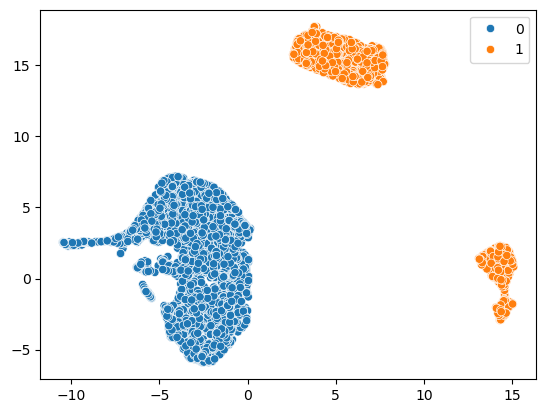

In [27]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

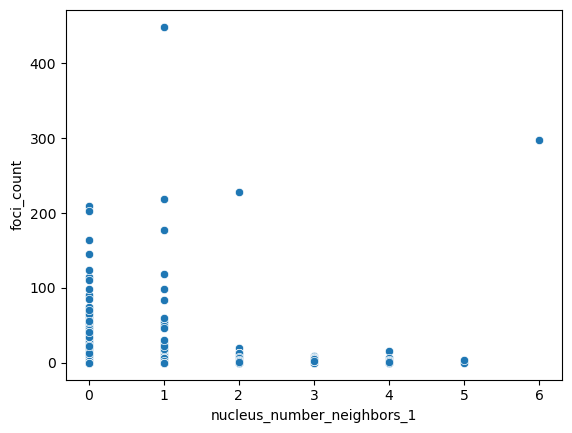

In [32]:
sns.scatterplot(data=df, x="nucleus_number_neighbors_1", y="foci_count")
plt.show()

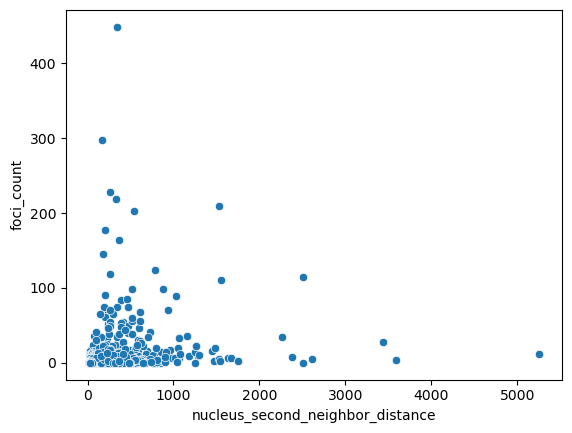

In [40]:
sns.scatterplot(data=df, x="nucleus_second_neighbor_distance", y="foci_count")
plt.show()

<Axes: xlabel='nucleus_number_neighbors_1', ylabel='foci_count'>

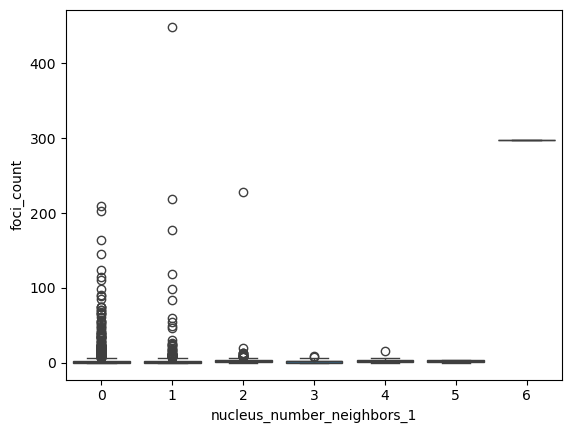

In [34]:
sns.boxplot(data=df, x="nucleus_number_neighbors_1", y="foci_count")

In [43]:
df2=df
df["density_2"] = 2 / (np.pi * df2["nucleus_second_neighbor_distance"]**2)

<Axes: xlabel='density_2', ylabel='foci_count'>

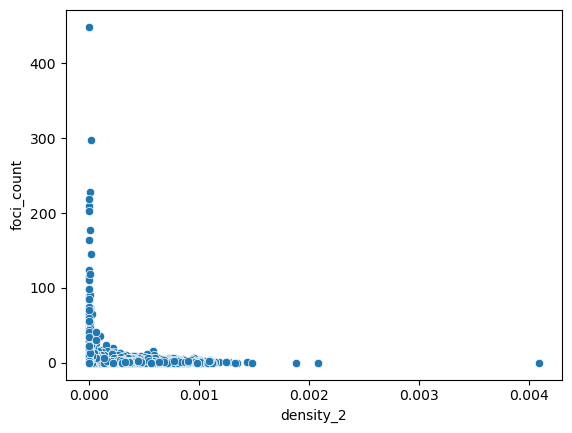

In [46]:
sns.scatterplot(data=df, x="density_2", y="foci_count")

<Axes: xlabel='density_2', ylabel='foci_count'>

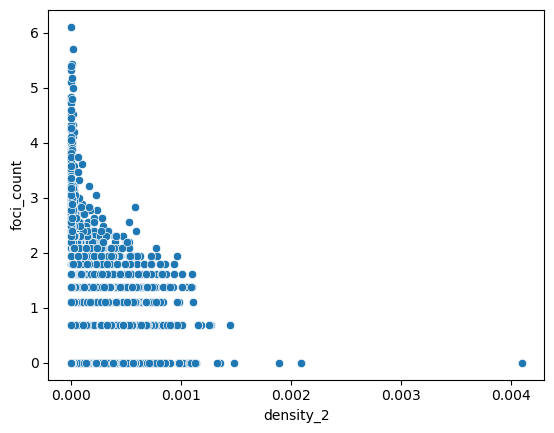

In [47]:
sns.scatterplot(
    data=df,
    x="density_2",
    y=np.log1p(df["foci_count"])
)

<Axes: xlabel='density_bin', ylabel='foci_count'>

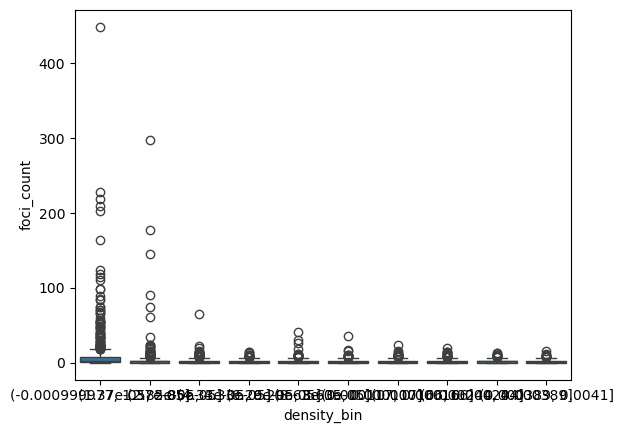

In [48]:
df["density_bin"] = pd.qcut(df["density_2"], 10)

sns.boxplot(
    data=df,
    x="density_bin",
    y="foci_count"
)

In [49]:
df["crowding"] = 1 / (
    df["nucleus_first_neighbor_distance"] +
    df["nucleus_second_neighbor_distance"]
)

In [57]:
data["nuclei_i"]

0         702.826279
1         725.440191
2         827.004931
3         846.331606
4        1058.934964
            ...     
5579    41141.648562
5580    41229.020349
5581    41330.006431
5582    41327.680887
5583    41340.798928
Name: nuclei_i, Length: 5584, dtype: float64

In [59]:
df3 = pd.concat([df, data[["nuclei_i"] + ["nuclei_j"]]], axis=1, join="outer", sort=False).reset_index()

In [60]:
df3

,index,foci_count,nuclei_area,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors,distance_bin,density_2,density_bin,crowding,nuclei_i,nuclei_j
0,0,4,2717.0,84,1,0.269625,45.028147,356.689278,63.122746,"(35.517, 49.204]",5.003801e-06,"(-0.000999977, 1.37e-05]",0.002489,702.826279,23104.128082
1,1,0,1672.0,0,1,0.373206,45.028147,338.722585,110.067377,"(35.517, 49.204]",5.548707e-06,"(-0.000999977, 1.37e-05]",0.002606,725.440191,23143.065789
2,2,115,47858.0,2292,0,0.000000,2285.094352,2508.669848,75.143949,"(109.452, 5209.19]",1.011563e-07,"(-0.000999977, 1.37e-05]",0.000209,827.004931,19604.518137
3,3,209,69456.0,2352,0,0.000000,1485.149163,1525.921370,0.727305,"(109.452, 5209.19]",2.734109e-07,"(-0.000999977, 1.37e-05]",0.000332,846.331606,24623.286484
4,4,4,1799.0,39,0,0.000000,338.722585,356.689278,6.809877,"(109.452, 5209.19]",5.003801e-06,"(-0.000999977, 1.37e-05]",0.001438,1058.934964,23083.784880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5579,5579,0,313.0,0,0,0.000000,198.964734,650.819766,29.652683,"(109.452, 5209.19]",1.502999e-06,"(-0.000999977, 1.37e-05]",0.001177,41141.648562,21164.952077
5580,5580,0,344.0,0,0,0.000000,198.964734,487.943582,138.708792,"(109.452, 5209.19]",2.673874e-06,"(-0.000999977, 1.37e-05]",0.001456,41229.020349,20986.197674
5581,5581,0,622.0,0,1,0.157025,24.680533,53.098282,28.441146,"(4.3069999999999995, 35.517]",2.257975e-04,"(0.000166, 0.000244]",0.012857,41330.006431,23561.048232
5582,5582,0,586.0,0,0,0.000000,33.524676,53.098282,20.524922,"(4.3069999999999995, 35.517]",2.257975e-04,"(0.000166, 0.000244]",0.011544,41327.680887,23614.095563


In [63]:
df = df3

In [64]:
from sklearn.neighbors import NearestNeighbors

coords = df[["nuclei_i","nuclei_j"]].values

nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
distances, _ = nbrs.kneighbors(coords)

rk = distances[:,5]

df["density_k5"] = 5 / (np.pi * rk**2)

In [65]:
df

,index,foci_count,nuclei_area,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors,distance_bin,density_2,density_bin,crowding,nuclei_i,nuclei_j,density_k5
0,0,4,2717.0,84,1,0.269625,45.028147,356.689278,63.122746,"(35.517, 49.204]",5.003801e-06,"(-0.000999977, 1.37e-05]",0.002489,702.826279,23104.128082,3.479666e-07
1,1,0,1672.0,0,1,0.373206,45.028147,338.722585,110.067377,"(35.517, 49.204]",5.548707e-06,"(-0.000999977, 1.37e-05]",0.002606,725.440191,23143.065789,3.580777e-07
2,2,115,47858.0,2292,0,0.000000,2285.094352,2508.669848,75.143949,"(109.452, 5209.19]",1.011563e-07,"(-0.000999977, 1.37e-05]",0.000209,827.004931,19604.518137,1.971550e-07
3,3,209,69456.0,2352,0,0.000000,1485.149163,1525.921370,0.727305,"(109.452, 5209.19]",2.734109e-07,"(-0.000999977, 1.37e-05]",0.000332,846.331606,24623.286484,3.700783e-07
4,4,4,1799.0,39,0,0.000000,338.722585,356.689278,6.809877,"(109.452, 5209.19]",5.003801e-06,"(-0.000999977, 1.37e-05]",0.001438,1058.934964,23083.784880,4.919935e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5579,5579,0,313.0,0,0,0.000000,198.964734,650.819766,29.652683,"(109.452, 5209.19]",1.502999e-06,"(-0.000999977, 1.37e-05]",0.001177,41141.648562,21164.952077,1.816631e-06
5580,5580,0,344.0,0,0,0.000000,198.964734,487.943582,138.708792,"(109.452, 5209.19]",2.673874e-06,"(-0.000999977, 1.37e-05]",0.001456,41229.020349,20986.197674,2.212551e-06
5581,5581,0,622.0,0,1,0.157025,24.680533,53.098282,28.441146,"(4.3069999999999995, 35.517]",2.257975e-04,"(0.000166, 0.000244]",0.012857,41330.006431,23561.048232,5.732854e-07
5582,5582,0,586.0,0,0,0.000000,33.524676,53.098282,20.524922,"(4.3069999999999995, 35.517]",2.257975e-04,"(0.000166, 0.000244]",0.011544,41327.680887,23614.095563,5.728589e-07


In [66]:
df["density_k5"].describe()

count    5.584000e+03
mean     1.277548e-04
std      1.546546e-04
min      3.857237e-08
25%      3.303967e-05
50%      7.815936e-05
75%      1.555887e-04
max      1.277333e-03
Name: density_k5, dtype: float64

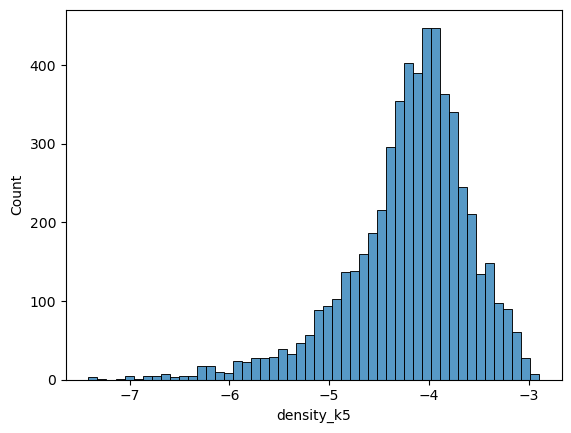

In [ ]:
sns.histplot(df["density_k5"], bins=50)
plt.show()

In [70]:
df["log_density_k5"] = np.log10(df["density_k5"])
df["log_foci"] = np.log1p(df["foci_count"])

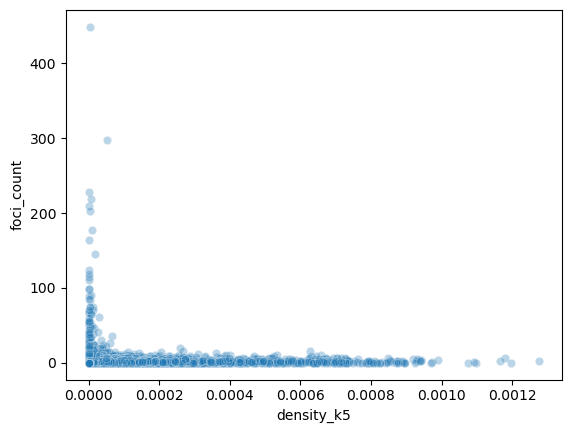

In [91]:
sns.scatterplot(
    data=df,
    x="density_k5",
    y="foci_count",
    alpha=0.3
)
plt.show()

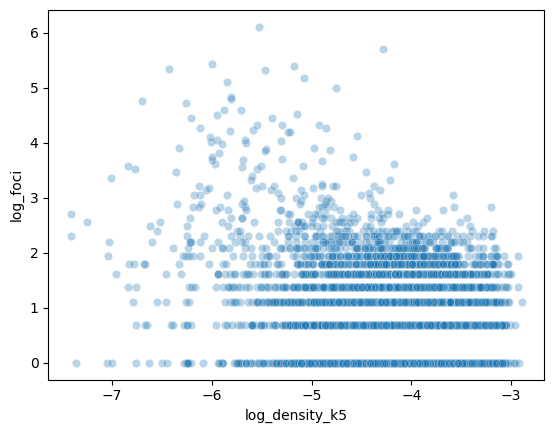

In [71]:
sns.scatterplot(
    data=df,
    x="log_density_k5",
    y="log_foci",
    alpha=0.3
)
plt.show()

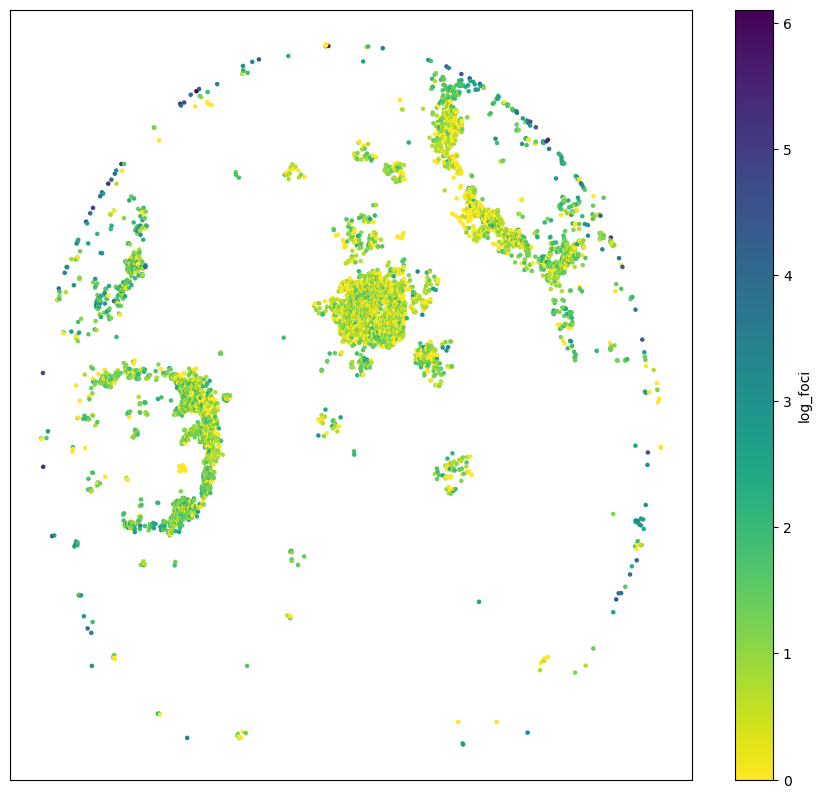

In [85]:
plt.figure(figsize=(11,10))

plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_foci"],
    s=5,
    cmap="viridis_r"
)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="log_foci")
plt.gca().invert_yaxis()
plt.show()

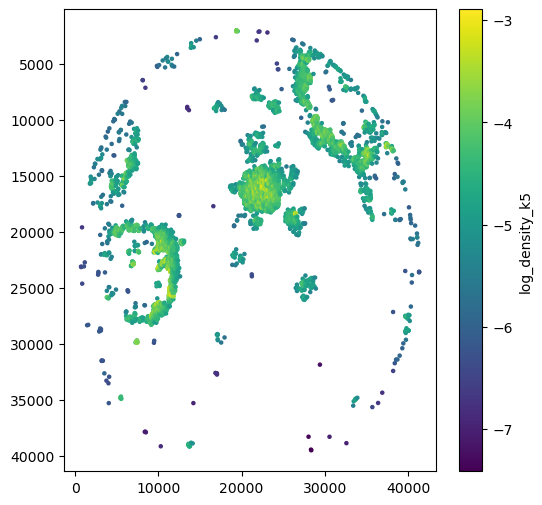

In [73]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=5,
    cmap="viridis"
)

plt.colorbar(label="log_density_k5")
plt.gca().invert_yaxis()
plt.show()

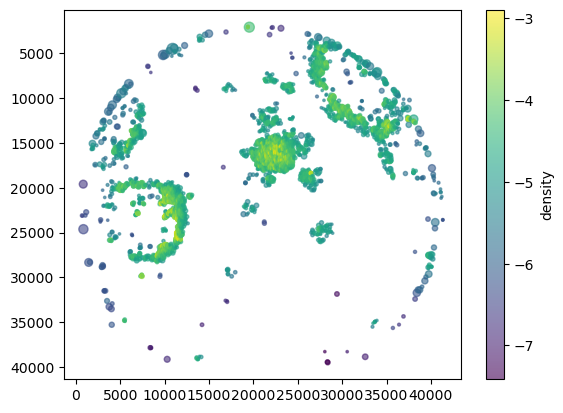

In [79]:
plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=np.sqrt(df["foci_count"]+1)*3,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="density")
plt.gca().invert_yaxis()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = df.copy()

df["log_density_k5"] = np.log(df["density_k5"])
# safer if any zeros might exist:
# df["log_density_k5"] = np.log1p(df["density_k5"])

model = smf.glm(
    formula="foci_count ~ log_density_k5 + nuclei_area",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(model.summary())

model.

                 Generalized Linear Model Regression Results                  
Dep. Variable:             foci_count   No. Observations:                 5584
Model:                            GLM   Df Residuals:                     5581
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11451.
Date:                Sun, 15 Mar 2026   Deviance:                       5540.0
Time:                        21:18:02   Pearson chi2:                 4.81e+03
No. Iterations:                    41   Pseudo R-squ. (CS):             0.4112
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.7323      0.110     -6.

/Users/hannahbolen/miniforge3/envs/slide_env/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


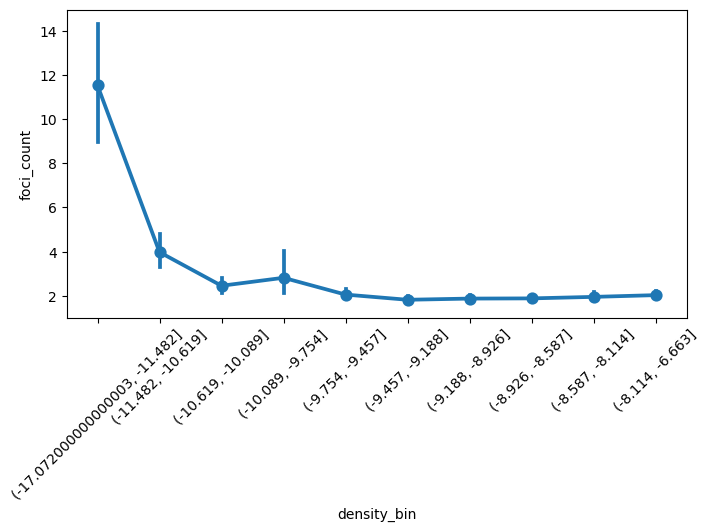

In [87]:
df["density_bin"] = pd.qcut(df["log_density_k5"], 10)

plt.figure(figsize=(8,4))

sns.pointplot(
    data=df,
    x="density_bin",
    y="foci_count",
    errorbar=("ci",95)
)

plt.xticks(rotation=45)
plt.show()